<a href="https://colab.research.google.com/github/Abdulwaliy/Flyrank-ML-Internship/blob/main/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdulwaliy/Flyrank-ML-Internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print("Lane 4: CTR / Engagement Opportunity Scoring")



Lane 4: CTR / Engagement Opportunity Scoring


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*


This work supports a prioritization decision: which pages a content or SEO team should spend limited review time on in a given week or sprint. The person acting on it is likely a content strategist or SEO analyst, not an automated system — the output is a candidate list with reasons attached, not a change that gets pushed automatically. A wrong recommendation has an asymmetric cost depending on direction: flagging a page that's actually fine wastes review time and may lead to an unnecessary rewrite of a title/meta that was working; missing a genuinely underperforming page means lost clicks and traffic keep accumulating silently. Given the skew found in Section 3 (mean-based tier baselines likely over-flag pages), the near-term risk leans toward false positives — flagging too many pages — which argues for treating this as a ranked shortlist for human review, not a definitive verdict, at least until the baseline is refined to something like median CTR.

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.




## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df.head()



,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## **Number 1 — CTR by position tier**

In [15]:
tier_ctr = df.groupby('position_tier')['ctr'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
tier_ctr

,mean,median,count
position_tier,,,
top_3,1.483611,0.00,2321
page_1,0.652467,0.16,11814
striking,0.323239,0.11,7304
page_3_5,0.222484,0.03,7242
deep,0.150212,0.00,1319


## **Number 2 — Gap candidates with enough volume**

In [16]:
# expected CTR per tier
tier_expected = df.groupby('position_tier')['ctr'].transform('mean')
df['ctr_gap'] = df['ctr'] - tier_expected
df['ctr_gap_pct'] = df['ctr_gap'] / tier_expected

# thresholds — tune these once you see the distribution
GAP_THRESHOLD = -0.25       # 25% below tier average
MIN_IMPRESSIONS = 500       # adjust based on impressions_last_30d distribution

candidates = df[(df['ctr_gap_pct'] < GAP_THRESHOLD) & (df['impressions_last_30d'] >= MIN_IMPRESSIONS)]

print(f"Total pages: {len(df)}")
print(f"Review candidates (gap < {GAP_THRESHOLD:.0%}, impressions_last_30d >= {MIN_IMPRESSIONS}): {len(candidates)}")
print(f"Share of pages flagged: {len(candidates) / len(df):.1%}")

Total pages: 30000
Review candidates (gap < -25%, impressions_last_30d >= 500): 6359
Share of pages flagged: 21.2%


## **Number 3 — Noise check: does low volume exaggerate the gap?**

In [17]:
# split into low vs high volume, compare gap spread
low_vol = df[df['impressions_last_30d'] < MIN_IMPRESSIONS]
high_vol = df[df['impressions_last_30d'] >= MIN_IMPRESSIONS]

print("Low volume pages — ctr_gap_pct std:", low_vol['ctr_gap_pct'].std())
print("High volume pages — ctr_gap_pct std:", high_vol['ctr_gap_pct'].std())
print("Low volume pages — % with |gap| > 50%:", (low_vol['ctr_gap_pct'].abs() > 0.5).mean())
print("High volume pages — % with |gap| > 50%:", (high_vol['ctr_gap_pct'].abs() > 0.5).mean())

Low volume pages — ctr_gap_pct std: 7.887805319980769
High volume pages — ctr_gap_pct std: 0.8112301567094847
Low volume pages — % with |gap| > 50%: 0.8610575067541489
High volume pages — % with |gap| > 50%: 0.6453839516824849


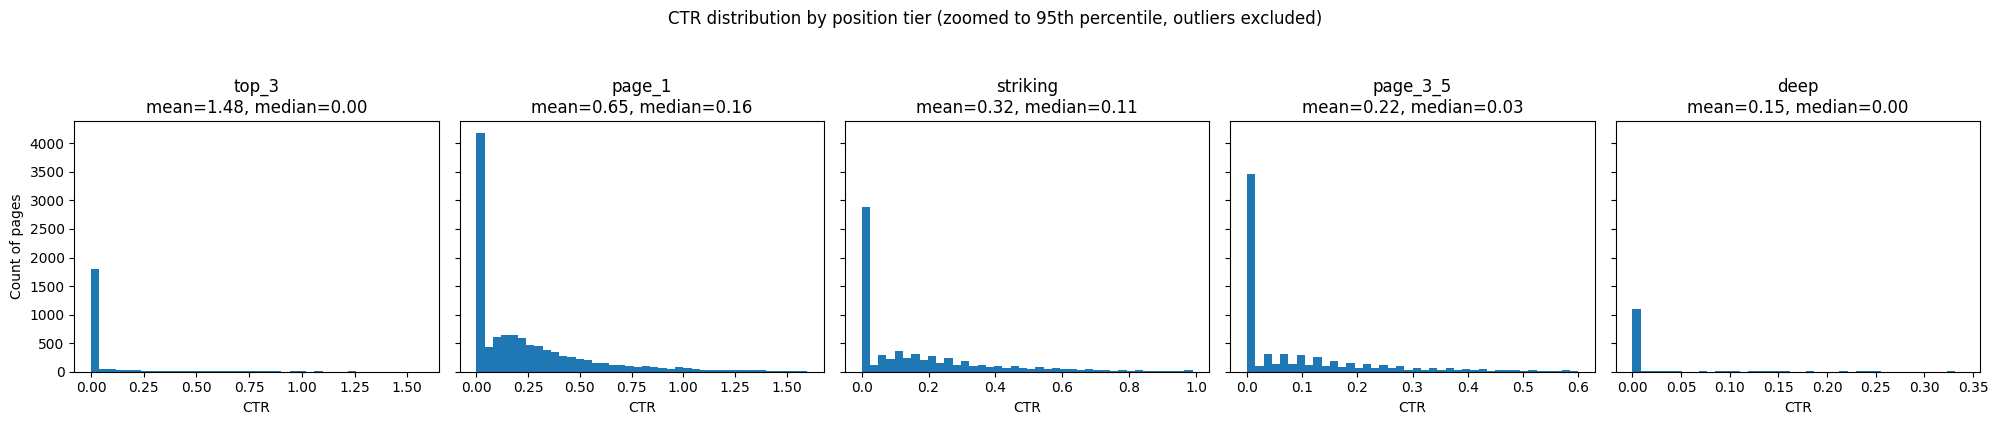

In [20]:
fig, axes = plt.subplots(1, len(tiers_ordered), figsize=(20, 4), sharey=True)

for ax, tier in zip(axes, tiers_ordered):
    subset = df[df['position_tier'] == tier]['ctr']
    ax.hist(subset, bins=40, range=(0, subset.quantile(0.95)))
    ax.set_title(f"{tier}\nmean={subset.mean():.2f}, median={subset.median():.2f}")
    ax.set_xlabel("CTR")

axes[0].set_ylabel("Count of pages")
plt.suptitle("CTR distribution by position tier (zoomed to 95th percentile, outliers excluded)", y=1.05)
plt.tight_layout()
plt.show()

CTR is heavily right-skewed within every position tier — most pages cluster near zero, while a small number of extreme outliers (some near 100% CTR) pull the mean well above the median. This confirms that a mean-based "expected CTR" baseline is distorted by a handful of pages, likely low-volume ones where a single click produces an inflated rate. This is direct visual evidence for using a median-based (or volume-weighted) baseline instead of the mean when computing tier-adjusted gaps.


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*


This analysis can say a page's CTR is low relative to other pages in the same position tier, using the available data — that's an observed, relative comparison, not a judgment about the page's intrinsic quality. It can point to directional patterns, like which pages have the largest gap-adjusted-for-volume, as candidates worth a human look. It can support a decision — it is decision support, prioritizing attention, not an automated verdict.
It cannot claim that a low CTR is caused by a specific factor like title wording, meta description, or content quality — the data shown here doesn't establish causation, only correlation with position and volume. It cannot predict how Google's ranking or click behavior will change in response to any edit. And given the skew shown in Section 3 (tier means pulled up by a small number of high performers), even the "low relative to tier" claim should be treated cautiously until a more robust baseline (e.g. median-based) is validated — at 30% mean-based flagging with likely over-counting, some fraction of flagged pages are probably false positives, not real problems.

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.